# Reproduce & tweak the paper's figures

Every **emulator-free** figure and table in the paper (the derivative-faithfulness
taxonomy, the diagnostic figures, the budget/seed studies, the multi-D summary) is
regenerated here from the committed data via one reusable module,
`priya_forecast.paper_figures`. **No GP, PySR, or Julia** — only the light deps in
`requirements-figures.txt`. Change a keyword, re-run a cell, and the figure updates:
this is meant to be edited.

The prediction figures (Fig 1/3/4) need the GP emulator — see `REPRODUCE.md` Step 2.

## 0. Setup

`pip install -r requirements-figures.txt` and run from the repo root with `src/` on the path (or `pip install -e .`). A TeX install is only needed for LaTeX labels — pass `usetex=False` below if you don't have one.

In [1]:
import os, sys
from pathlib import Path
# Make this work no matter where the notebook is launched: walk up to the repo
# root (the dir containing src/priya_forecast), chdir there, put src/ on the path.
_root = Path.cwd()
while _root != _root.parent and not (_root / "src" / "priya_forecast").is_dir():
    _root = _root.parent
os.chdir(_root); sys.path.insert(0, "src")     # or `pip install -e .`
import matplotlib.pyplot as plt
from priya_forecast import paper_figures as pf

# Load ONE run. No hard-coded paths: data_dir defaults to the committed run,
# but pass any run dir (or override the sub-paths) to reuse this on new data:
#   run = pf.load_run("results/my_other_run", z=3.6)
run = pf.load_run()
print("repo:", _root.name, "| z =", run.z, "| params with sidecars:", len(run.sidecars)//2)

repo: lya1d_priya_forecast | z = 3.6 | params with sidecars: 11


## 1. Tables

### Table 6 — the derivative-faithfulness taxonomy (the main result)

In [2]:
tax = pf.taxonomy(run)          # value vs Sobolev knee grad_err + class, per parameter
tax.round(3)

,param,value_grad_err,sobolev_grad_err,class
0,dtau0,0.009,0.003,faithful
1,tau0,0.006,0.005,faithful
2,ns,0.365,0.160,faithful
3,Ap,0.298,0.155,faithful
4,herei,0.079,0.084,faithful
5,heref,0.105,0.045,faithful
6,alphaq,0.126,0.134,faithful
7,hub,0.986,1.000,resistant
8,omegamh2,0.697,0.063,faithful
9,hireionz,0.266,0.167,faithful


**Read it (at z=3.6):** 9/11 parameters are `faithful` under Sobolev here; `hub` + `bhfeedback` `resistant`. `ns` goes 0.365 (value) → 0.160 (Sobolev). **Caveat:** this is the z=3.6 snapshot — per-z the faithful count is 8/9/6 at z=2.6/3.6/4.2, and only 5 parameters (dtau0, tau0, Ap, omegamh2, hireionz) are faithful at *all three* redshifts; `ns` is faithful only at z=3.6 (and borderline there). Use `pf.load_run(z=2.6)` / `pf.plot_crossz(run)` to see the z-dependence, and `pf.taxonomy(run, gate=0.30)` to change the gate.

### Table 7 — the knee-selected equation metrics per parameter

In [3]:
pf.equations(run, loss="sobolev").round(4)   # try loss="value" to compare

,param,complexity,loss,grad_err
0,dtau0,19,0.0022,0.0027
1,tau0,20,0.0024,0.0052
2,ns,18,9.7466,0.1603
3,Ap,19,13.5519,0.1546
4,herei,18,0.7172,0.0839
5,heref,20,18.8792,0.0454
6,alphaq,10,27.4870,0.1338
7,hub,10,422.0077,1.0000
8,omegamh2,11,75.0296,0.0630
9,hireionz,19,8.5766,0.1667


## 2. Figures

Every `plot_*` returns a Matplotlib `Figure` you can restyle or save. Wrap calls in `pf.paper_style()` for the large LaTeX look; it is fully overridable — e.g. `pf.paper_style(usetex=False, scale=1.3)`.

### 2.1 Scorecard — value vs Sobolev, one point per parameter

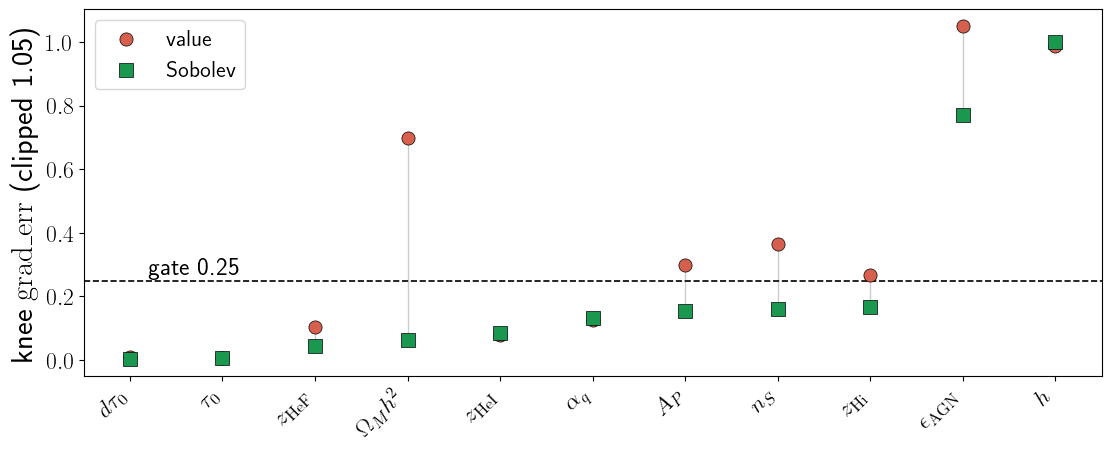

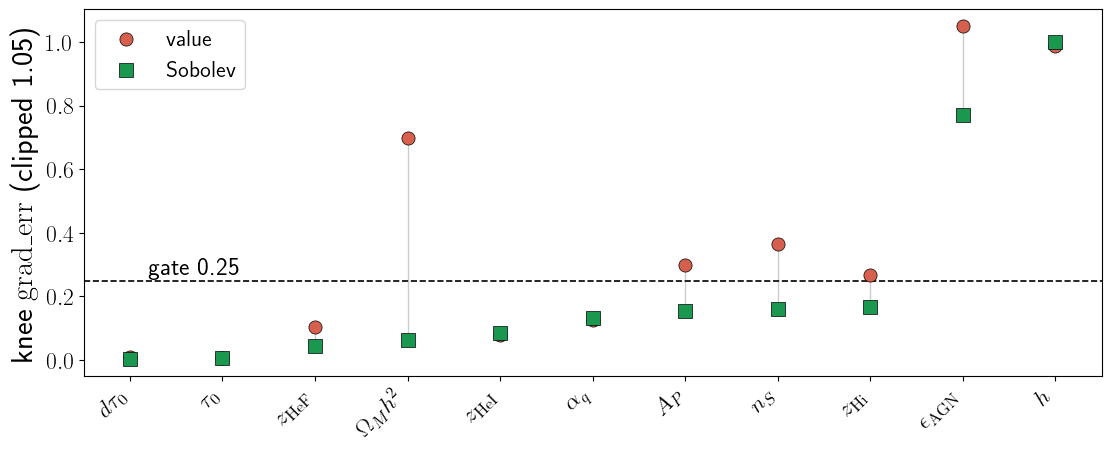

In [4]:
with pf.paper_style():                # try: pf.paper_style(usetex=False, scale=1.2)
    fig = pf.plot_scorecard(run)      # tweak: pf.plot_scorecard(run, gate=0.30)
fig                                    # (or fig.savefig("scorecard.pdf"))

### 2.2 Maxsize sensitivity — the reframe's key evidence

Value-loss faithfulness *falls with the search budget* (and is seed-fragile), while Sobolev is already faithful at maxsize=20. Change which parameters are highlighted:

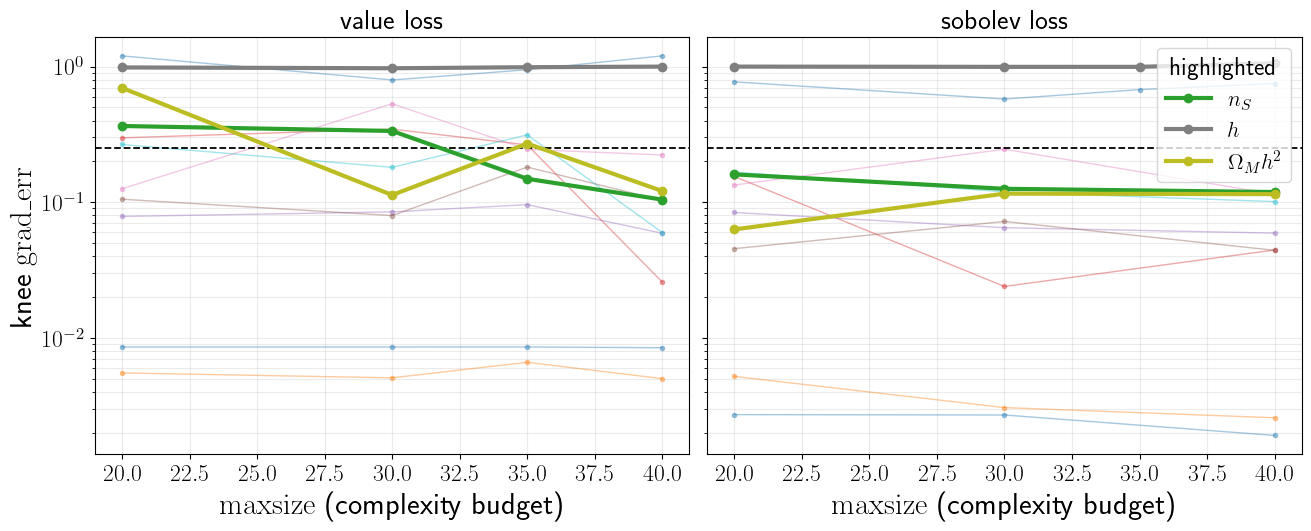

In [5]:
with pf.paper_style():
    fig = pf.plot_maxsize_sensitivity(run, highlight=("ns", "omegamh2", "hub"))
fig

### 2.3 Across-seed band

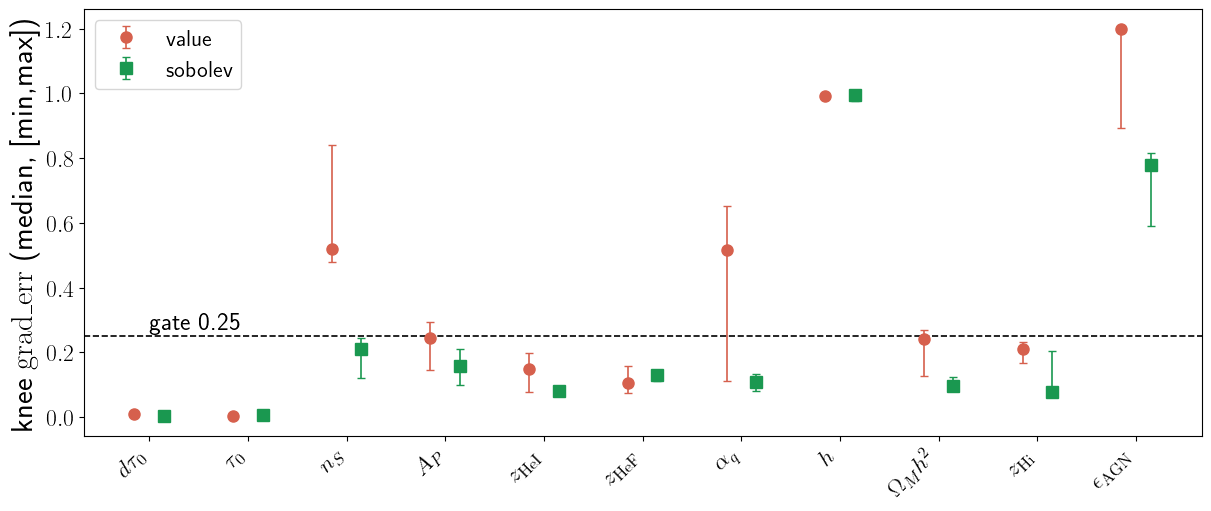

In [6]:
with pf.paper_style():
    fig = pf.plot_seed_band(run)
fig

### 2.4 The n_S budget panel

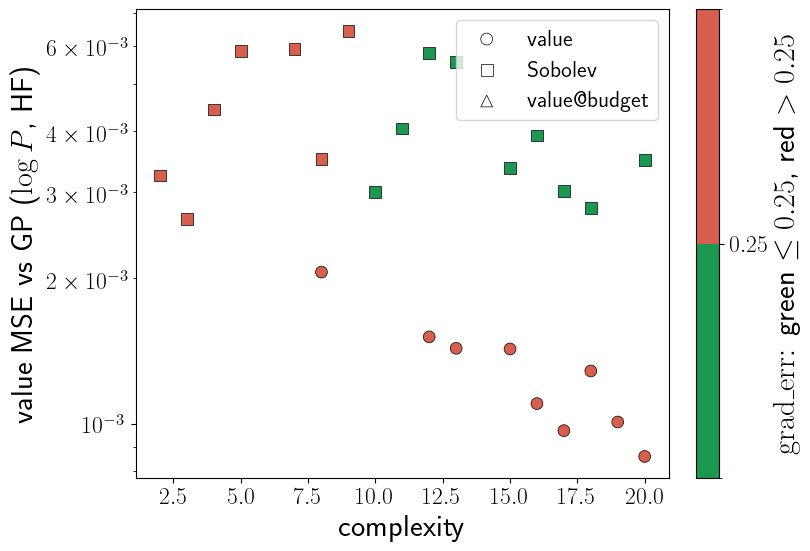

In [7]:
with pf.paper_style():
    fig = pf.plot_ns_budget(run)
fig

### 2.5 Cross-redshift robustness

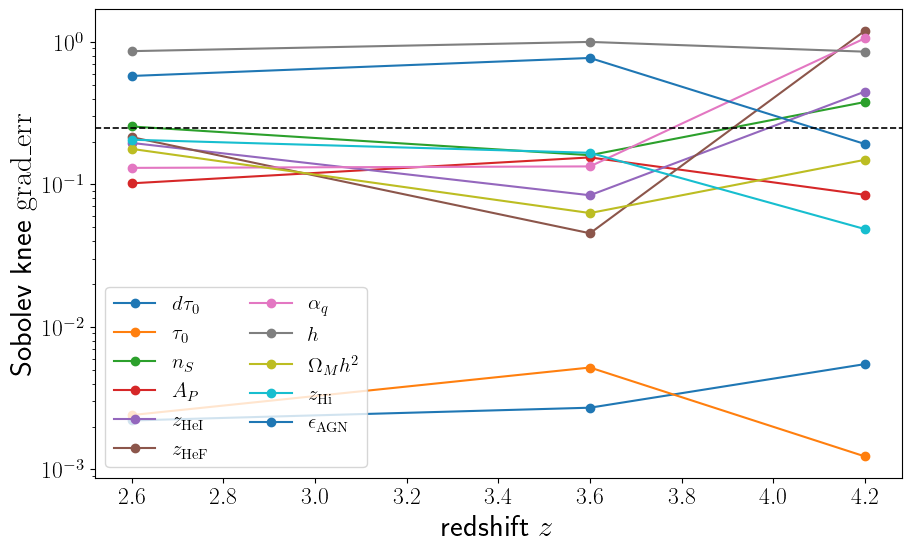

In [8]:
with pf.paper_style():
    fig = pf.plot_crossz(run)
fig

### 2.6 Multi-D combine accuracy

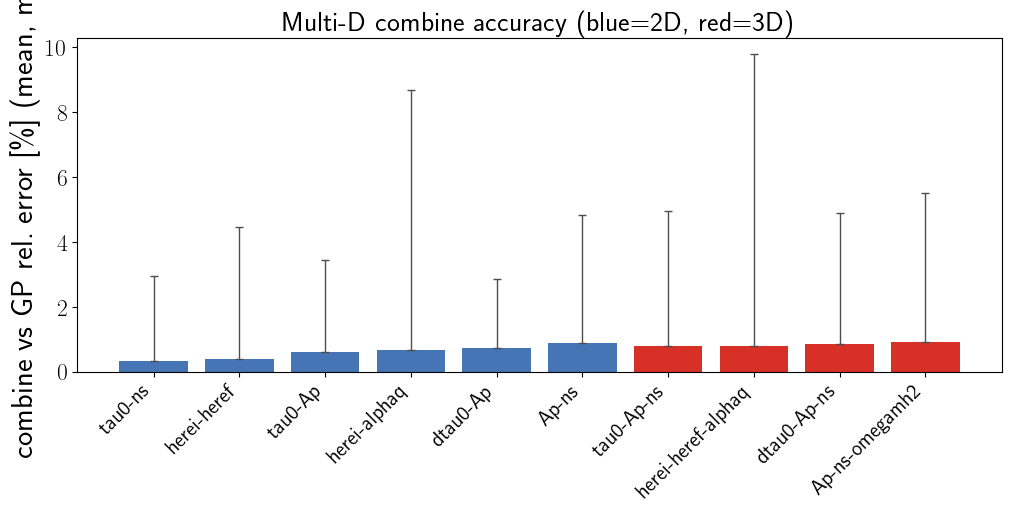

In [9]:
with pf.paper_style():
    fig = pf.plot_multid(run)
fig

### 2.7 The 11-panel Pareto-faithfulness grid (the central figure)

This one delegates to the shared renderer and *writes a file* (it is a grid, not a single Figure). Then display it:

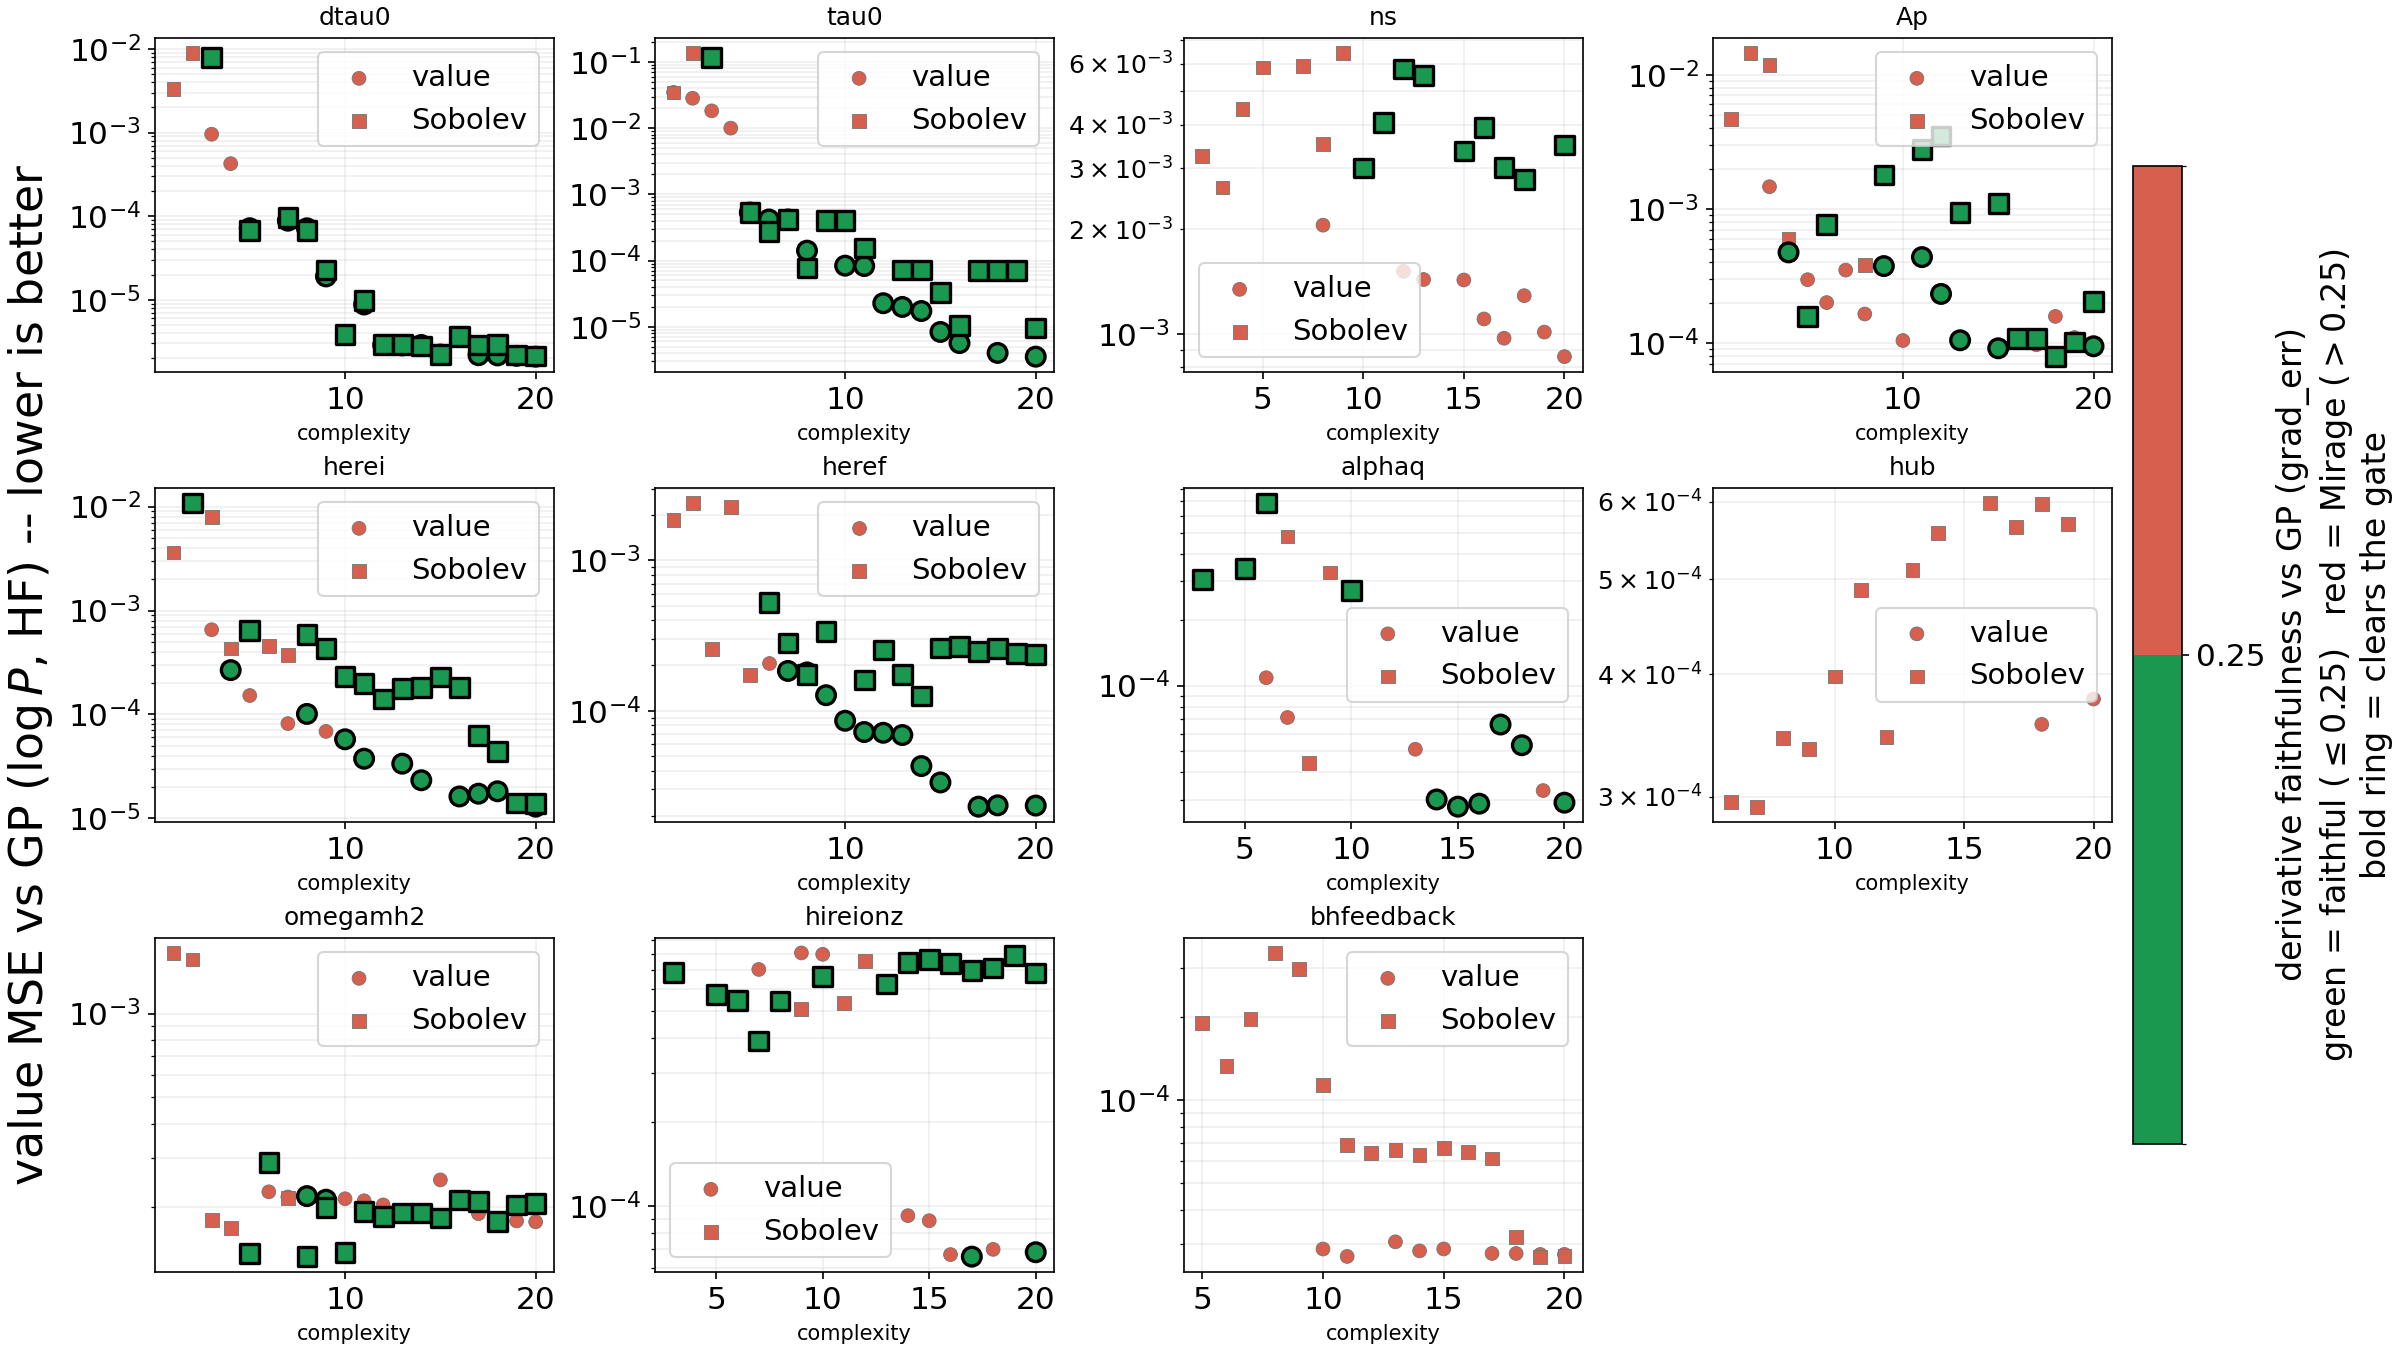

In [10]:
from IPython.display import Image
out = "pareto_faithfulness_tutorial.png"
pf.plot_pareto_faithfulness(run, out)     # writes `out` at dpi 150
Image(out)

## 3. Tweak it — a worked example

The functions are ordinary Matplotlib. Restyle globally via `paper_style`, or grab the returned `Figure`/`Axes` and edit. Example: no-LaTeX, bigger, custom colours:

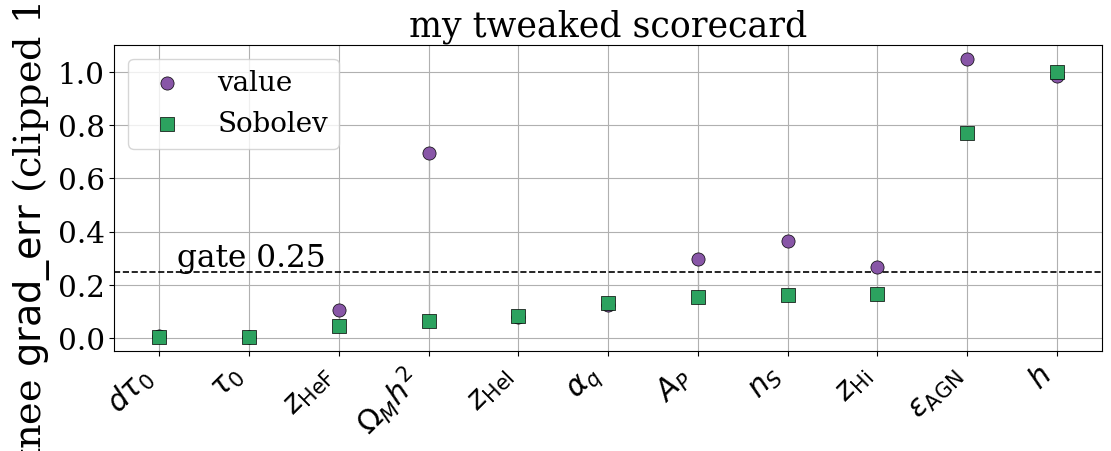

In [11]:
pf.C_VALUE, pf.C_SOBOLEV = "#8856a7", "#2ca25f"     # recolour the series
with pf.paper_style(usetex=False, scale=1.25, **{"axes.grid": True}):
    fig = pf.plot_scorecard(run)
    fig.axes[0].set_title("my tweaked scorecard")
fig

## 4. Reuse on a different run

Nothing above hard-codes a path. Point `load_run` at another run directory (same layout) and every figure/table regenerates:

In [12]:
# run2 = pf.load_run("results/single_z_z2.6_sobolev", z=2.6, sobolev_sub=".", value_sub=".")
# pf.taxonomy(run2)
print("See load_run's docstring for the sub-path overrides.")

See load_run's docstring for the sub-path overrides.
